In [1]:
import os
import json
import itertools
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

## 1. CARGA DE INSUMOS DEL MÓDULO 1

In [2]:
SALIDAS = "salidas"
ruta_json = f"{SALIDAS}/resultados_m1.json"

if not os.path.exists(ruta_json):
    raise FileNotFoundError(f"No se encontró {ruta_json}. Ejecuta el Módulo 1 primero.")

with open(ruta_json, "r", encoding="utf-8") as f:
    datos_m1 = json.load(f)

TICKERS = datos_m1["tickers"]
N = datos_m1["n_acciones"]
CAPITAL_INICIAL = datos_m1["capital_inicial"]
PESOS_OPTIMOS = np.array([datos_m1["markowitz_max_sharpe"]["pesos"][t] for t in TICKERS])

# Descargar datos mensuales para la simulación DP
print("Descargando datos para simulación multiperiodo...")
precios = yf.download(TICKERS, start="2015-01-01", end="2024-12-31", progress=False)['Close']
precios = precios.dropna(how="all").ffill().bfill()
precios_mensuales = precios.resample('ME').last()
retornos_mensuales = precios_mensuales.pct_change().dropna()

Descargando datos para simulación multiperiodo...


/tmp/ipykernel_3853/3213470194.py:17: FutureWarning: YF.download() has changed argument auto_adjust default to True
  precios = yf.download(TICKERS, start="2015-01-01", end="2024-12-31", progress=False)['Close']


## 2. CONFIGURACIÓN DE PARÁMETROS DP

In [3]:
LAMBDA_TC = 0.001       # Costo de transacción (0.1%)
PASO_GRILLA = 0.25      # Discretización (0.0, 0.25, 0.50, 0.75, 1.0)
T_PERIODOS = min(12, len(retornos_mensuales)) # Horizonte DP (ej. últimos 12 meses)

print(f"Generando grilla de estados con paso {PASO_GRILLA}...")
# Generación de la grilla de estados válidos (pesos que suman 1)
def generar_grilla(n, paso):
    valores = np.arange(0.0, 1.0 + paso, paso)
    grilla = []
    for combinacion in itertools.product(valores, repeat=n):
        if np.isclose(sum(combinacion), 1.0):
            grilla.append(np.array(combinacion))
    return grilla

estados = generar_grilla(N, PASO_GRILLA)
num_estados = len(estados)
print(f"Estados generados: {num_estados}")

Generando grilla de estados con paso 0.25...
Estados generados: 70


## 3. ALGORITMO DP (BACKWARD INDUCTION)

In [4]:
# Costos de transición
def costo_transaccion(w_actual, w_nuevo):
    return LAMBDA_TC * np.sum(np.abs(w_nuevo - w_actual))

def costo_suboptimalidad(w):
    # Penaliza la desviación del portafolio óptimo de Markowitz
    return np.sum((w - PESOS_OPTIMOS)**2)

# Matrices de DP
V = np.zeros((T_PERIODOS + 1, num_estados))  # Función de valor (costo mínimo)
Politica = np.zeros((T_PERIODOS, num_estados), dtype=int) # Decisiones óptimas

print("Ejecutando Backward Induction (Bellman)...")
for t in range(T_PERIODOS - 1, -1, -1):
    for i, estado_actual in enumerate(estados):
        costos_opciones = np.zeros(num_estados)

        for j, estado_nuevo in enumerate(estados):
            # Costo inmediato: TC + Suboptimalidad
            costo_inmediato = costo_transaccion(estado_actual, estado_nuevo) + costo_suboptimalidad(estado_nuevo)
            # Costo futuro esperado (asumiendo transición determinista en la grilla para simplificar)
            costo_futuro = V[t + 1, j]
            costos_opciones[j] = costo_inmediato + costo_futuro

        V[t, i] = np.min(costos_opciones)
        Politica[t, i] = np.argmin(costos_opciones)

Ejecutando Backward Induction (Bellman)...


## 4. SIMULACIÓN DE ESTRATEGIAS (FORWARD)

In [5]:
riqueza_bh = np.zeros(T_PERIODOS + 1)
riqueza_sr = np.zeros(T_PERIODOS + 1)
riqueza_dp = np.zeros(T_PERIODOS + 1)

riqueza_bh[0] = riqueza_sr[0] = riqueza_dp[0] = CAPITAL_INICIAL

pesos_bh = PESOS_OPTIMOS.copy()
pesos_dp = PESOS_OPTIMOS.copy()
ret_sim = retornos_mensuales.iloc[-T_PERIODOS:].values
fechas_sim = retornos_mensuales.index[-T_PERIODOS-1:]

rebalanceos_dp = []

# Encontrar el estado más cercano en la grilla
def encontrar_estado_cercano(w, estados):
    distancias = [np.linalg.norm(w - e) for e in estados]
    return np.argmin(distancias)

for t in range(T_PERIODOS):
    r_t = ret_sim[t]

    # 1. Buy & Hold
    ret_bh = np.dot(pesos_bh, r_t)
    riqueza_bh[t+1] = riqueza_bh[t] * (1 + ret_bh)
    pesos_bh = pesos_bh * (1 + r_t) / (1 + ret_bh) # Deriva del mercado

    # 2. Siempre Rebalancear (a PESOS_OPTIMOS)
    costo_tc_sr = costo_transaccion(pesos_bh, PESOS_OPTIMOS) # Asumiendo deriva similar
    ret_sr = np.dot(PESOS_OPTIMOS, r_t) - costo_tc_sr
    riqueza_sr[t+1] = riqueza_sr[t] * (1 + ret_sr)

    # 3. DP Optimizado
    idx_estado_actual = encontrar_estado_cercano(pesos_dp, estados)
    idx_decision = Politica[t, idx_estado_actual]
    nuevo_w_dp = estados[idx_decision]

    if idx_decision != idx_estado_actual:
        rebalanceos_dp.append(t)

    costo_tc_dp = costo_transaccion(pesos_dp, nuevo_w_dp)
    ret_dp = np.dot(nuevo_w_dp, r_t) - costo_tc_dp
    riqueza_dp[t+1] = riqueza_dp[t] * (1 + ret_dp)
    pesos_dp = nuevo_w_dp * (1 + r_t) / (1 + ret_dp)

## 5. VISUALIZACIONES

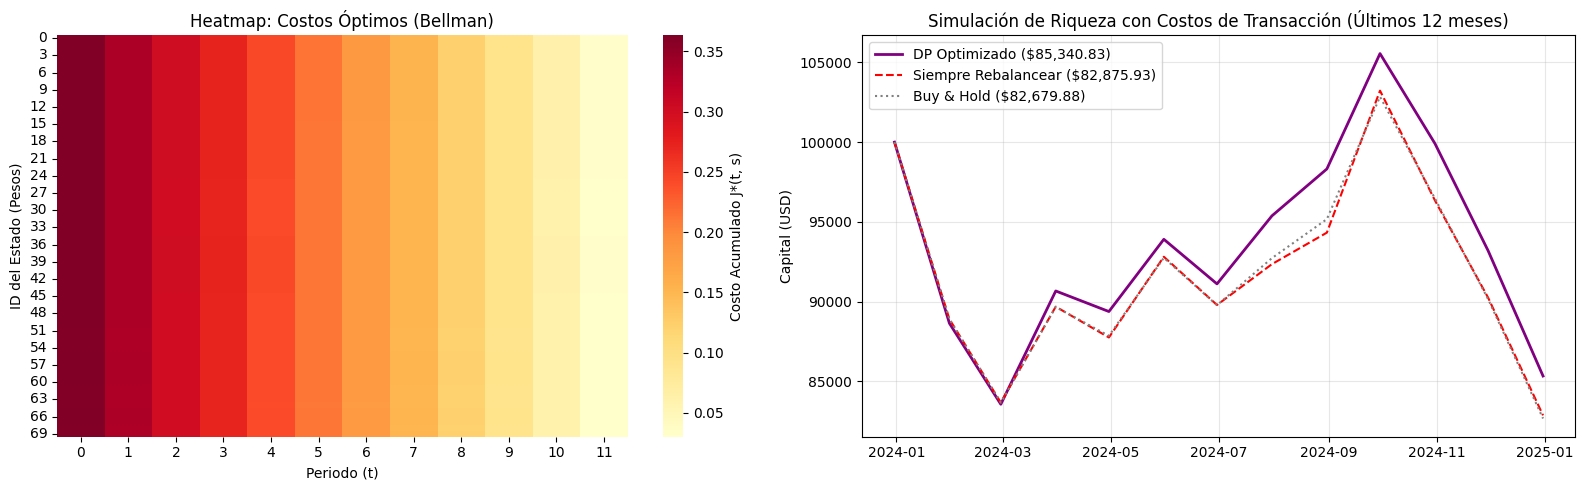

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Gráfico 1: Heatmap de la tabla DP (Costos Óptimos)
sns.heatmap(V[:-1, :].T, cmap="YlOrRd", ax=axes[0], cbar_kws={'label': 'Costo Acumulado J*(t, s)'})
axes[0].set_title("Heatmap: Costos Óptimos (Bellman)")
axes[0].set_xlabel("Periodo (t)")
axes[0].set_ylabel("ID del Estado (Pesos)")

# Gráfico 2: Evolución de Riqueza
axes[1].plot(fechas_sim, riqueza_dp, label=f"DP Optimizado (${riqueza_dp[-1]:,.2f})", color='purple', lw=2)
axes[1].plot(fechas_sim, riqueza_sr, label=f"Siempre Rebalancear (${riqueza_sr[-1]:,.2f})", color='red', ls='--')
axes[1].plot(fechas_sim, riqueza_bh, label=f"Buy & Hold (${riqueza_bh[-1]:,.2f})", color='gray', ls=':')

# Marcar momentos de rebalanceo DP
for t_reb in rebalanceos_dp:
    axes[1].axvline(fechas_sim[t_reb+1], color='purple', alpha=0.3, ls='-')

axes[1].set_title("Simulación de Riqueza con Costos de Transacción (Últimos 12 meses)")
axes[1].set_ylabel("Capital (USD)")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{SALIDAS}/fig_dp_rebalanceo.png", dpi=130)
plt.show()

## 6. EXPORTACIÓN DE RESULTADOS M3

In [7]:
resultados_m3 = {
    "parametros_dp": {
        "lambda_tc": LAMBDA_TC,
        "periodos_t": T_PERIODOS,
        "paso_grilla": PASO_GRILLA,
        "total_estados": num_estados
    },
    "riqueza_final": {
        "buy_and_hold": float(riqueza_bh[-1]),
        "siempre_rebalancear": float(riqueza_sr[-1]),
        "dp_optimizado": float(riqueza_dp[-1])
    },
    "timeline_rebalanceos_dp": rebalanceos_dp
}

with open(f"{SALIDAS}/resultados_m3.json", "w", encoding="utf-8") as f:
    json.dump(resultados_m3, f, ensure_ascii=False, indent=2)

print(f"\nArchivo del Módulo 3 guardado exitosamente: {SALIDAS}/resultados_m3.json")


Archivo del Módulo 3 guardado exitosamente: salidas/resultados_m3.json
